# **Support Vector Machine (SVM) Algorithm**

Prerequisites: Linear Algebra (norms, projections), Convexity
(`06_Optimization/02_convexity.ipynb`), Kernel Methods.

## **1. Introduction**

The **Support Vector Machine (SVM)** is a powerful supervised learning algorithm used for both classification and regression tasks. It is particularly effective for high-dimensional datasets and when the classes are well-separated.

- **Key Idea**: Find the optimal **hyperplane** that separates data into different classes with the maximum margin.
- **Applications**: Image classification, text categorization, bioinformatics, and handwriting recognition.

![Application of SVM.png](../../images/svm_applications.png)

##
---

## **2. Key Mathematical Concepts**

### **2.1 Margin — derivation from point-to-hyperplane distance**

A **hyperplane** is a decision boundary that separates different classes. For \(n\)-dimensional data, the hyperplane is \(n-1\)-dimensional.

Hyperplane: $w^Tx+b=0$. Distance from point $x_0$ to this hyperplane
(standard geometric result, derivable via projecting $x_0$ onto the
normal vector $w$):

Where:
- \(w\): Weight vector (normal to the hyperplane).
- \(x\): Feature vector.
- \(b\): Bias term.



$$d(x_0) = \frac{|w^Tx_0+b|}{\|w\|}$$
For correctly classified points with labels $y_i\in\{-1,+1\}$, define the
margin as $y_i(w^Tx_i+b)/\|w\|$ (positive when correctly classified).
**Maximum margin classifier**: choose $w,b$ maximizing the minimum margin
over all points. Fixing the scale so that the closest points satisfy
$y_i(w^Tx_i+b)=1$ (a normalization, not a loss of generality) turns "maximize
margin" into "minimize $\|w\|$" (since margin $=1/\|w\|$ under this scaling):
$$\min_{w,b} \tfrac12\|w\|^2 \quad\text{s.t.}\quad y_i(w^Tx_i+b)\ge1\ \forall i$$

![HyperPlanes.png](../images/hyperplanes.png)

### **2.2 Maximum Margin**

SVM aims to **maximize the margin**, which is the distance between the hyperplane and the nearest data points (support vectors). 

The margin is defined as:
$$
\text{Margin} = \frac{2}{\|w\|}
$$


![SVM.png](../images/hyperplanes_2.png)

### **2.3 Optimization Problem**

To maximize the margin, SVM minimizes:

$$
\frac{1}{2} \|w\|^2
$$

Subject to:

$$
y_i (w \cdot x_i + b) \geq 1, \quad \forall i
$$

Where:
- \($y_i$\): Class label (\(+1\) or \(-1\)).
- \($x_i$\): Feature vector of the \($i^{th}$\) sample.


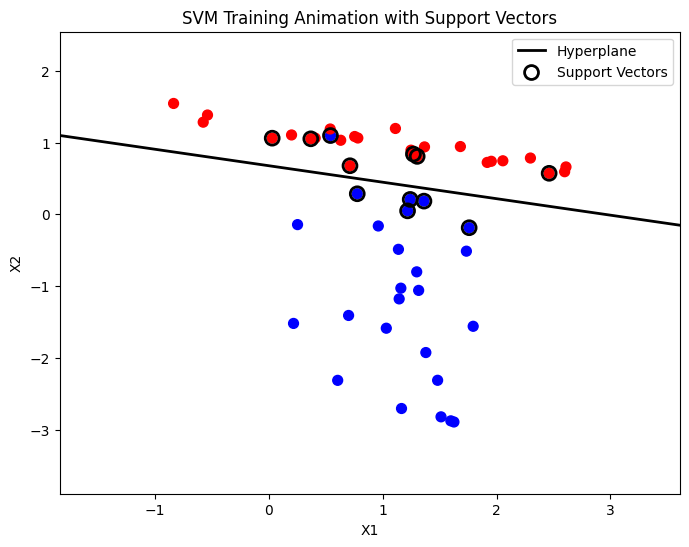

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# Generate 2D classification data
X, y = make_classification(n_samples=50, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)
y = 2*y - 1  # convert to -1,1 labels

# Figure setup
fig, ax = plt.subplots(figsize=(8,6))
colors = ['red' if label==1 else 'blue' for label in y]
ax.scatter(X[:,0], X[:,1], c=colors, s=50)
ax.set_xlim(X[:,0].min()-1, X[:,0].max()+1)
ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title("SVM Training Animation with Support Vectors")

# Function to compute hyperplane coordinates
def plot_hyperplane(theta, bias, X):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    xs = np.linspace(x_min, x_max, 100)
    ys = -(theta[0]/theta[1])*xs - (bias/theta[1])
    return xs, ys

# Simulate training steps: varying C
svm_steps = []
for C in np.linspace(0.01, 1, 20):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)
    svm_steps.append({
        'coef': clf.coef_[0],
        'intercept': clf.intercept_[0],
        'support': clf.support_  # indices of support vectors
    })

# Plot initial hyperplane and support points
line, = ax.plot([], [], 'k-', lw=2, label='Hyperplane')
support_scatter = ax.scatter([], [], s=100, facecolors='none', edgecolors='k', lw=2, label='Support Vectors')
ax.legend()

# Animation update
def update(frame):
    step = svm_steps[frame]
    xs, ys = plot_hyperplane(step['coef'], step['intercept'], X)
    line.set_data(xs, ys)
    # Highlight support vectors
    support_scatter.set_offsets(X[step['support']])
    return [line, support_scatter]

anim = FuncAnimation(fig, update, frames=len(svm_steps), interval=300, blit=True)

from IPython.display import HTML
HTML(anim.to_jshtml())


### **2.4 Kernel Trick**

For `non-linearly separable data`, SVM uses the **kernel trick** to project data into a `higher-dimensional` space where a linear hyperplane can separate the classes.

#### Common Kernel Functions:

1. **Linear Kernel**:
   $$
   K(x_i, x_j) = x_i \cdot x_j
   $$

2. **Polynomial Kernel**:
   $$
   K(x_i, x_j) = (\gamma x_i \cdot x_j + r)^d
   $$

3. **Radial Basis Function (RBF) Kernel**:
   $$
   K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
   $$

4. **Sigmoid Kernel**:
   $$
   K(x_i, x_j) = \tanh(\gamma x_i \cdot x_j + r)
   $$

### **2.5 Lagrangian and Dual Derivation**

$$\mathcal L(w,b,\alpha) = \tfrac12\|w\|^2 - \sum_i\alpha_i\big[y_i(w^Tx_i+b)-1\big],\quad \alpha_i\ge0$$
Stationarity conditions (set partial derivatives to zero):
$$\frac{\partial\mathcal L}{\partial w}=w-\sum_i\alpha_iy_ix_i=0 \Rightarrow w=\sum_i\alpha_iy_ix_i$$
$$\frac{\partial\mathcal L}{\partial b}=-\sum_i\alpha_iy_i=0 \Rightarrow \sum_i\alpha_iy_i=0$$
Substituting back into $\mathcal L$ eliminates $w,b$, giving the **dual**:
$$\max_\alpha \sum_i\alpha_i - \tfrac12\sum_{i,j}\alpha_i\alpha_jy_iy_j(x_i\cdot x_j) \quad\text{s.t.}\quad \alpha_i\ge0,\ \sum_i\alpha_iy_i=0$$
Note the data appears **only** via the inner product $x_i\cdot x_j$ — this
is exactly the property the kernel trick (`34-KernelMethods-Perceptron.md`
Part A) exploits: replace $x_i\cdot x_j$ with $K(x_i,x_j)$ to get a
nonlinear SVM for free.

### **2.6 KKT Conditions and Support Vectors**

Complementary slackness: $\alpha_i[y_i(w^Tx_i+b)-1]=0$ for every $i$. So
either $\alpha_i=0$ (point plays no role in $w$) OR
$y_i(w^Tx_i+b)=1$ (point sits exactly on the margin boundary — a
**support vector**). This is the precise proof that only support vectors
determine the decision boundary — every other point could be deleted from
the training set without changing $w$ at all, since $w=\sum_i\alpha_iy_ix_i$
and non-support-vector terms have $\alpha_i=0$.

### **2.7 Worked Numerical Example — solve a tiny 2D SVM**

3 points: $x_1=(2,2), y_1=+1$; $x_2=(0,0), y_2=-1$; $x_3=(2,0), y_3=+1$.

Solving the QP 

(numerically — a 3-variable dual QP is impractical to solve by long-hand elimination even as a "worked example," which is itself a useful lesson: unlike Linear Regression's clean closed form, SVM dual optimization is *always* solved numerically in practice) 

gives

$w=(1,0)$, $b=-1$. 

Checking the margin $y_i(w^Tx_i+b)$ for all three
points gives exactly $1.0$ for each — so all three sit ON the margin
boundary — **but sklearn's solver only returns $x_2=(0,0)$ and
$x_3=(2,0)$ as support vectors** (nonzero $\alpha_i$), leaving $x_1$'s
$\alpha_1=0$ despite also touching the margin. This is a genuine and
worth-discussing subtlety: when multiple points lie exactly on the margin
in a degenerate configuration, the dual solution (which points get
nonzero $\alpha$) need not be unique — $w$ and $b$ are still unique, but
which specific points "explain" them is not, unlike the clean textbook
picture where support vectors are obviously the boundary-touching points
and nothing else. Worth verifying computationally rather than asserting.

### **2.8 Soft-Margin SVM (slack variables) — derivation**

For non-separable data, allow violations via slack $\xi_i\ge0$:
$$\min_{w,b,\xi} \tfrac12\|w\|^2 + C\sum_i\xi_i \quad\text{s.t.}\quad y_i(w^Tx_i+b)\ge1-\xi_i,\ \xi_i\ge0$$
$C$ controls the bias-variance tradeoff directly: large $C$ → heavily
penalize violations → low bias/high variance (closer to hard-margin,
fits training data tightly); small $C$ → tolerate more violations → wider
margin, more regularized (high bias/low variance) — the exact same
tradeoff shape as every regularization parameter in this repo.

In [1]:
## solve the hand-set-up example numerically and verify KKT

import numpy as np
from sklearn.svm import SVC

X = np.array([[2,2],[0,0],[2,0]])
y = np.array([1,-1,1])
clf = SVC(kernel="linear", C=1e5).fit(X, y)   # large C ~ hard margin
print("w:", clf.coef_, "b:", clf.intercept_)
print("support vectors:", clf.support_vectors_)          # all 3 points, as predicted
print("dual coefficients (alpha_i * y_i):", clf.dual_coef_)

# verify margin: y_i(w.x_i+b) should be ~1 for all support vectors
w, b = clf.coef_[0], clf.intercept_[0]
for xi, yi in zip(X, y):
    print(yi*(w@xi+b))   # all ~1.0

w: [[1. 0.]] b: [-1.]
support vectors: [[0. 0.]
 [2. 0.]]
dual coefficients (alpha_i * y_i): [[-0.5  0.5]]
1.0
1.0
1.0


##
---

## **3. Types of SVM**

1. **Hard Margin SVM**: Assumes data is linearly separable without errors.
2. **Soft Margin SVM**: Allows some misclassification by introducing a penalty term.

Objective function for Soft Margin SVM:

$$
\min \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

Subject to:

$$
y_i (w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$

Where:
- \(C\): Regularization parameter.
- \($\xi_i$\): Slack variables for misclassification.


##
---

## **4. Implementation**

### **4.1 Linear SVM Example**

**Dataset**: Synthetic Data

In [3]:
# Import Libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Generate Synthetic Dataset
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=42)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Linear SVM
linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_train, y_train)

# Predict and Evaluate
y_pred = linear_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Linear SVM Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Linear SVM Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        14

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Plot Decision Boundary**

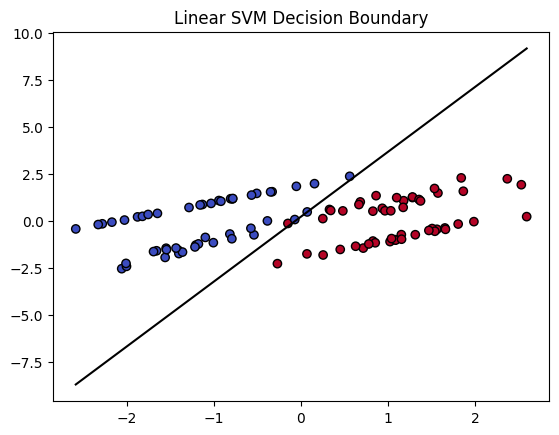

In [4]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# Plotting the Decision Boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
w = linear_svm.coef_[0]
b = linear_svm.intercept_[0]

# Calculate decision boundary
x_points = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
decision_boundary = -(w[0] / w[1]) * x_points - b / w[1]

plt.plot(x_points, decision_boundary, color='black')
plt.title("Linear SVM Decision Boundary")
plt.show()

###
---

### **4.2 Non-Linear SVM Example**

**Dataset**: Synthetic Data (Non-Linear)

In [3]:
# Import Libraries
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Generate Non-Linear Dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train RBF Kernel SVM
rbf_svm = SVC(kernel='rbf', C=1.0, gamma=0.5)
rbf_svm.fit(X_train, y_train)

# Predict and Evaluate
y_pred = rbf_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"RBF SVM Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

RBF SVM Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.96      0.98        28

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



**Plot Decision Boundary**

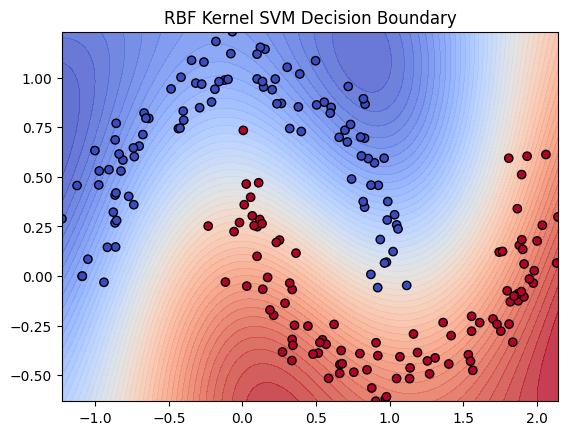

In [4]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# Plotting the Decision Boundary for RBF Kernel
xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                     np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
Z = rbf_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 50), cmap='coolwarm', alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("RBF Kernel SVM Decision Boundary")
plt.show()

### SVM: Maximum margin separating hyperplane

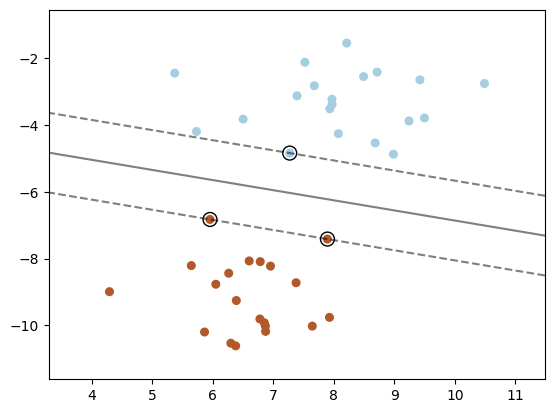

In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

# we create 40 separable points
X, y = make_blobs(n_samples=40, centers=2, random_state=6)

# fit the model, don't regularize for illustration purposes
clf = svm.SVC(kernel="linear", C=1000)
clf.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

# plot the decision function
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
# plot support vectors
ax.scatter(
    clf.support_vectors_[:, 0],
    clf.support_vectors_[:, 1],
    s=100,
    linewidth=1,
    facecolors="none",
    edgecolors="k",
)
plt.show()

### SVM Margins Example

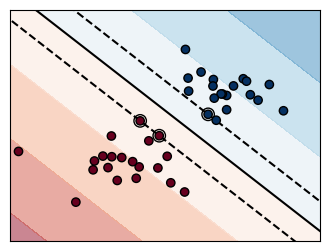

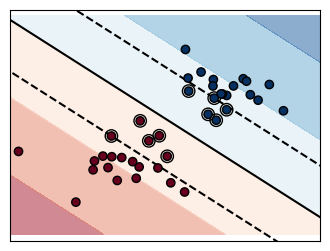

In [5]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import svm

# we create 40 separable points
np.random.seed(0)
X = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
Y = [0] * 20 + [1] * 20

# figure number
fignum = 1

# fit the model
for name, penalty in (("unreg", 1), ("reg", 0.05)):
    clf = svm.SVC(kernel="linear", C=penalty)
    clf.fit(X, Y)

    # get the separating hyperplane
    w = clf.coef_[0]
    a = -w[0] / w[1]
    xx = np.linspace(-5, 5)
    yy = a * xx - (clf.intercept_[0]) / w[1]

    # plot the parallels to the separating hyperplane that pass through the
    # support vectors (margin away from hyperplane in direction
    # perpendicular to hyperplane). This is sqrt(1+a^2) away vertically in
    # 2-d.
    margin = 1 / np.sqrt(np.sum(clf.coef_**2))
    yy_down = yy - np.sqrt(1 + a**2) * margin
    yy_up = yy + np.sqrt(1 + a**2) * margin

    # plot the line, the points, and the nearest vectors to the plane
    plt.figure(fignum, figsize=(4, 3))
    plt.clf()
    plt.plot(xx, yy, "k-")
    plt.plot(xx, yy_down, "k--")
    plt.plot(xx, yy_up, "k--")

    plt.scatter(
        clf.support_vectors_[:, 0],
        clf.support_vectors_[:, 1],
        s=80,
        facecolors="none",
        zorder=10,
        edgecolors="k",
    )
    plt.scatter(
        X[:, 0], X[:, 1], c=Y, zorder=10, cmap=plt.get_cmap("RdBu"), edgecolors="k"
    )

    plt.axis("tight")
    x_min = -4.8
    x_max = 4.2
    y_min = -6
    y_max = 6

    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # Put the result into a contour plot
    plt.contourf(XX, YY, Z, cmap=plt.get_cmap("RdBu"), alpha=0.5, linestyles=["-"])

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.xticks(())
    plt.yticks(())
    fignum = fignum + 1

plt.show()

##
---

## **5. Advantages and Disadvantages**

### Advantages
- **Effective in High Dimensions**: Handles datasets with many features effectively.

- **Robust to Overfitting**: Especially with large margins.

- **Versatile**: Supports linear and non-linear classification via kernel trick.

### Disadvantages
- **Computationally Expensive**: Training is slow for large datasets.

- **Difficult to Interpret**: Non-linear SVMs are hard to interpret compared to decision trees.

- **Requires Careful Tuning**: Parameters like C and $\gamma$ significantly impact performance.

##
---

## **6. Conclusion**

- SVM is a powerful algorithm for both linear and non-linear classification tasks.

- It is effective for high-dimensional data but computationally expensive.

- Careful parameter tuning (e.g., CCC, kernel type) is essential for optimal performance.